## Imports

In [53]:
from collections import defaultdict

import numpy as np
import pandas as pd
from imblearn.over_sampling import SMOTEN
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    f1_score,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
    auc,
)
from sklearn.model_selection import RandomizedSearchCV, learning_curve, train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from xgboost import XGBClassifier
from ydata_profiling import ProfileReport

import matplotlib.pyplot as plt
import matplotlib_inline
import seaborn as sns

## Load data

In [2]:
df = pd.read_csv(
    "/home/tii/datasets/customer_churn/WA_Fn-UseC_-Telco-Customer-Churn.csv",
    dtype=defaultdict(
        pd.StringDtype,
        MonthlyCharges=pd.Float32Dtype(),
        SeniorCitizen=pd.Int32Dtype(),
        tenure=pd.Int32Dtype(),
        TotalCharges=pd.Float32Dtype(),
    ),
    na_values=[pd.NA, " "],
)

## Observe

In [3]:
report = ProfileReport(df)
report.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 21/21 [00:00<00:00, 33.99it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

## Data preprocessing

In [4]:
df = df.dropna(subset=["TotalCharges"])
features, labels = df.drop(columns=["customerID", "Churn"], errors="ignore"), df.loc[:, "Churn"]

label_col = ["Churn"]
categorical_cols = features.select_dtypes(include=pd.StringDtype()).columns.to_list()
numerical_cols = features.select_dtypes(include=["number"]).columns.to_list()

print(f"""\
Label: {label_col}
Feature columns:
    Numeric: {categorical_cols}
    Categorical: {numerical_cols}
""")

Label: ['Churn']
Feature columns:
    Numeric: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
    Categorical: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']



In [17]:
train_features_transformer = ImbPipeline(
    steps=[
        (
            "encoder",
            ColumnTransformer(
                transformers=[
                    (
                        "cat_encoder",
                        OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore"),
                        categorical_cols,
                    ),
                    ("num_encoder", StandardScaler(), numerical_cols),
                ],
                remainder="passthrough",
            ),
        ),
        ("oversampler", SMOTEN(random_state=42)),
    ]
)
label_encoder = LabelEncoder()
test_features_transflormer = train_features_transformer.named_steps["encoder"]

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    features,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels,
)
print("Training set shape:", X_train.shape, y_train.shape)
print("Testing set shape:", X_test.shape, y_test.shape)

X_train, y_train = train_features_transformer.fit_resample(X_train, y_train)
y_train = label_encoder.fit_transform(y_train)

X_test = test_features_transflormer.transform(X_test)
y_test = label_encoder.transform(y_test)

print("After preprocessing:")
print("Training set shape:", X_train.shape, y_train.shape)
print("Testing set shape:", X_test.shape, y_test.shape)

Training set shape: (5625, 19) (5625,)
Testing set shape: (1407, 19) (1407,)
After preprocessing:
Training set shape: (8260, 30) (8260,)
Testing set shape: (1407, 30) (1407,)


In [39]:
label_encoder.classes_

array(['No', 'Yes'], dtype=object)

preprocessor = ImbPipeline(
    steps=[
        (
            "preprocessor",
            ColumnTransformer(
                transformers=[
                    (
                        "cat_encoder",
                        OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore"),
                        categorical_cols,
                    ),
                    ("num_encoder", StandardScaler(), numerical_cols),
                ],
                remainder="passthrough",
            ),
        ),
        ("oversampler", SMOTEN(random_state=42)),
    ]
)
label_encoder = LabelEncoder()

X, y = preprocessor.fit_resample(features, labels)
y = label_encoder.fit_transform(y)
print("Target classes:", label_encoder.classes_)


## Train test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print("Training set shape:", X_train.shape, y_train.shape)
print("Testing set shape:", X_test.shape, y_test.shape)


## Modeling

In [8]:
model = RandomForestClassifier(
    n_estimators=500,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",
    max_depth=30,
    bootstrap=False,
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",30
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",False
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

## Testing

In [9]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

# Print key metrics
print("Model performance")
print(f"F1-score : {f1_score(y_test, y_pred):.4f}")
print(f"AUC-ROC  : {roc_auc_score(y_test, y_proba):.4f}\n")
print(classification_report(y_test, y_pred))

Model performance
F1-score : 0.8558
AUC-ROC  : 0.9327

              precision    recall  f1-score   support

           0       0.86      0.86      0.86      1033
           1       0.86      0.86      0.86      1033

    accuracy                           0.86      2066
   macro avg       0.86      0.86      0.86      2066
weighted avg       0.86      0.86      0.86      2066



In [ ]:
# Setup RandomizedSearchCV
search_model = RandomizedSearchCV(
    estimator=RandomForestClassifier(),  # baseline RF model
    param_distributions={
        "n_estimators": [100, 200, 500],  # number of trees
        "max_depth": [None, 10, 20, 30],  # tree depth
        "min_samples_split": [2, 5, 10],  # min samples to split an internal node
        "min_samples_leaf": [1, 2, 4, 8],  # min samples at a leaf node
        "max_features": ["sqrt"],  # number of features to consider at each split
        "bootstrap": [False],  # use bootstrap samples or full dataset
    },
    n_iter=20,  # number of parameter settings sampled
    scoring="f1",  # optimize for F1-score
    cv=5,  # 5-fold cross-validation
    return_train_score=True,
    random_state=42,
    n_jobs=-1,  # parallelize across all cores
    verbose=1,
)

search_model.fit(X_train, y_train)
model = search_model.best_estimator_
print("Best hyperopts:", search_model.best_params_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best hyperopts: {'n_estimators': 500, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 30, 'bootstrap': False}


In [56]:
y_pred = search_model.best_estimator_.predict(X_test)
y_proba = search_model.best_estimator_.predict_proba(X_test)[:, 1]

# Print key metrics
print("Model performance")
print(f"F1-score : {f1_score(y_test, y_pred):.4f}")
print(f"AUC-ROC  : {roc_auc_score(y_test, y_proba):.4f}\n")
print(classification_report(y_test, y_pred, target_names=["No churn", "Churn"], output_dict=False))

Model performance
F1-score : 0.5568
AUC-ROC  : 0.8127

              precision    recall  f1-score   support

    No churn       0.84      0.86      0.85      1033
       Churn       0.58      0.54      0.56       374

    accuracy                           0.77      1407
   macro avg       0.71      0.70      0.70      1407
weighted avg       0.77      0.77      0.77      1407



AUC-PR score: 0.587138219636349


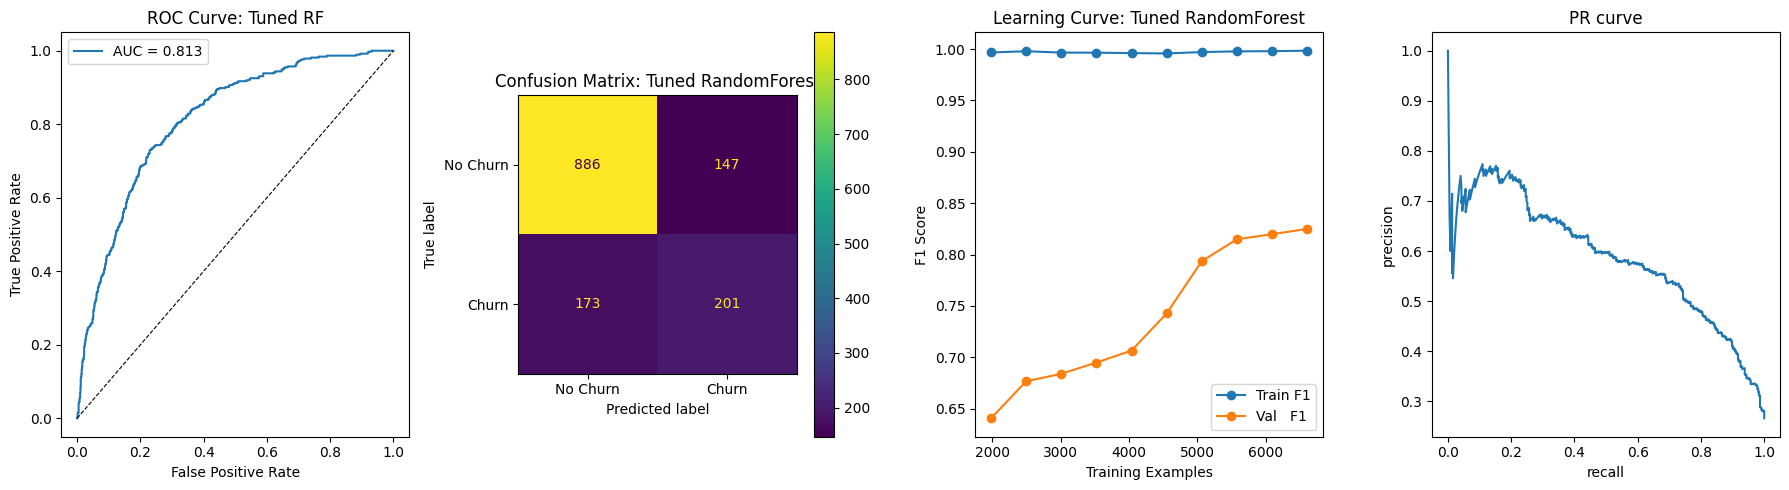

In [57]:
import warnings

# Plot ROC, confusion matrix, and learning curve for tuned RF
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
axes = axes.flatten()


#  b) ROC Curve
fpr_t, tpr_t, _ = roc_curve(y_test, y_proba)
axes[0].plot(fpr_t, tpr_t, label=f"AUC = {roc_auc_score(y_test, y_proba):.3f}")
axes[0].plot([0, 1], [0, 1], "k--", linewidth=0.8)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve: Tuned RF")
axes[0].legend()

#  c) Confusion Matrix
ConfusionMatrixDisplay.from_estimator(
    model,
    X_test,
    y_test,
    display_labels=["No Churn", "Churn"],
    ax=axes[1],
)
axes[1].set_title("Confusion Matrix: Tuned RandomForest")

#  a) Learning curve data (F1)
warnings.filterwarnings(action="module", module="_score")

train_sizes_t, train_scores_t, val_scores_t = learning_curve(
    model,
    X_train,
    y_train,
    train_sizes=np.linspace(0.3, 1.0, 10),
    scoring="f1",
    # n_jobs=-1,
    random_state=42,
)
train_mean_t = train_scores_t.mean(axis=1)
val_mean_t = val_scores_t.mean(axis=1)
#  d) Learning Curve (F1)
axes[2].plot(train_sizes_t, train_mean_t, marker="o", label="Train F1")
axes[2].plot(train_sizes_t, val_mean_t, marker="o", label="Val   F1")
axes[2].set_xlabel("Training Examples")
axes[2].set_ylabel("F1 Score")
axes[2].set_title("Learning Curve: Tuned RandomForest")
axes[2].legend()

# e) Precision-recall curve
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
pr_auc_score = auc(recall, precision)
print("AUC-PR score:", pr_auc_score)
axes[3].plot(recall, precision)
axes[3].set_title("PR curve")
axes[3].set_xlabel("recall")
axes[3].set_ylabel("precision")

plt.tight_layout()
plt.show()


In [ ]:
# Overfitting Check
print("Overfitting Checks")
for model in summary.index:
    for metric in ["F1-score", "AUC-ROC "]:
        gap = summary.loc[model, f"{metric} gap (Train–Test)"]
        status = "OVERFITTING" if gap > 0.05 else "No overfitting"
        print(f"{model} — {metric}: gap={gap:.3f} -> {status}")


Model performance
F1-score : 0.8558
AUC-ROC  : 0.9327

              precision    recall  f1-score   support

           0       0.86      0.86      0.86      1033
           1       0.86      0.86      0.86      1033

    accuracy                           0.86      2066
   macro avg       0.86      0.86      0.86      2066
weighted avg       0.86      0.86      0.86      2066

